<a href="https://colab.research.google.com/github/Acell-dot/Computer-Vision-and-Deep-Learning/blob/main/praktikum2_resnet50_Mode_Partial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 2: ResNet-50, satu mode (default `partial`)
Alur: siapkan data → tulis hipotesis → latih satu mode → catat hasil → ukur latensi → (opsional) uji foto sendiri.

**Sebelum mulai:** Runtime → Change runtime type → **T4 GPU**.

## Penyesuaian Dataset Baru
Di bawah ini adalah sel untuk mengunggah dan mendeteksi kelas secara otomatis dari dataset baru.

In [ ]:
import zipfile
import shutil
import random
from pathlib import Path
from google.colab import files
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

# 1. Bersihkan folder lama
!rm -rf dataset temp_extracted

print("Silakan unggah zip dataset:")
up_new = files.upload()
zip_path_new = next(iter(up_new))

# 2. Ekstrak ke folder sementara
with zipfile.ZipFile(zip_path_new) as z:
    z.extractall("temp_extracted")

# Cari tahu di mana folder kelas berada (bisa langsung di root atau di dalam subfolder)
temp_path = Path("temp_extracted")
subdirs = [p for p in temp_path.iterdir() if p.is_dir()]

# Jika hasil ekstrak dibungkus satu folder utama lagi (misal nama zip-nya)
if len(subdirs) == 1 and subdirs[0].name not in ["train", "val"]:
    base_dir = subdirs[0]
else:
    base_dir = temp_path

# Ambil semua folder kelas yang ada
class_folders = [p for p in base_dir.iterdir() if p.is_dir() and not p.name.startswith(".")]

print(f"Menemukan {len(class_folders)} kelas target: {[c.name for c in class_folders]}")

# 3. Buat struktur dataset/train dan dataset/val baru
for folder in class_folders:
    class_name = folder.name
    images = list(folder.glob("*"))
    random.seed(SEED)
    random.shuffle(images)

    # Bagi 80% Train, 20% Val
    split_idx = int(len(images) * 0.8)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    # Buat direktori tujuan
    Path(f"dataset/train/{class_name}").mkdir(parents=True, exist_ok=True)
    Path(f"dataset/val/{class_name}").mkdir(parents=True, exist_ok=True)

    for img in train_imgs:
        shutil.copy(img, f"dataset/train/{class_name}/{img.name}")
    for img in val_imgs:
        shutil.copy(img, f"dataset/val/{class_name}/{img.name}")

# Bersihkan file sampah sementara
!rm -rf temp_extracted

# 4. Inisialisasi ulang Dataset dan DataLoader
train_ds_new = datasets.ImageFolder("dataset/train", train_tf)
val_ds_new   = datasets.ImageFolder("dataset/val", val_tf)
classes_new = train_ds_new.classes

print("\n--- DATASET BARU BERHASIL DIKONFIGURASI ---")
print("Kelas baru:", classes_new)
print("Jumlah data train:", len(train_ds_new))
print("Jumlah data val:", len(val_ds_new))

train_dl = DataLoader(train_ds_new, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(device == "cuda"))
val_dl   = DataLoader(val_ds_new, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
classes = classes_new

Silakan unggah zip dataset:


Setelah menjalankan sel di atas dengan dataset baru, kita dapat melatih kembali model ResNet-50 dengan menjalankan ulang fungsi `build` dan loop pelatihan di langkah 3.

## Langkah 3: Training ResNet-50 pada Dataset Baru

In [ ]:
# Inisialisasi model baru dengan jumlah kelas baru
model, train_names = build(MODE, len(classes))
model.to(device)
n_train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Mode: {MODE} | Kelas: {classes} | Parameter dilatih: {n_train_params:,}")

crit = nn.CrossEntropyLoss()
opt = make_optimizer(model, MODE)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history, best_acc, best_epoch, epoch_ge_90, train_time = [], -1.0, 0, None, 0.0

# Loop pelatihan
for ep in range(1, EPOCHS + 1):
    sync(); t0 = time.perf_counter()
    set_train(model, train_names)
    tl, tc, n = 0.0, 0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward(); opt.step()
        tl += loss.item() * len(y); tc += (out.argmax(1) == y).sum().item(); n += len(y)
    sched.step()
    sync(); train_time += time.perf_counter() - t0
    vl, va, _, _ = evaluate(model, val_dl)
    history.append({"epoch": ep, "train_loss": tl / n, "train_acc": tc / n, "val_loss": vl, "val_acc": va})
    if va > best_acc:
        best_acc, best_epoch = va, ep
        torch.save(model.state_dict(), f"best_{MODE}.pt")
    if epoch_ge_90 is None and va >= 0.90:
        epoch_ge_90 = ep
    print(f"epoch {ep:2d} | train acc {tc/n:.3f} | val acc {va:.3f} | val loss {vl:.3f} | waktu kumulatif {train_time:.0f}s")

print(f"\nAkurasi val terbaik: {best_acc:.3f} (epoch {best_epoch})")

Mode: partial | Kelas: ['huruf_angka', 'panah'] | Parameter dilatih: 14,968,834
epoch  1 | train acc 0.718 | val acc 0.889 | val loss 0.214 | waktu kumulatif 3s
epoch  2 | train acc 0.878 | val acc 0.944 | val loss 0.143 | waktu kumulatif 5s
epoch  3 | train acc 0.909 | val acc 0.944 | val loss 0.156 | waktu kumulatif 8s
epoch  4 | train acc 0.913 | val acc 0.944 | val loss 0.140 | waktu kumulatif 12s
epoch  5 | train acc 0.923 | val acc 0.958 | val loss 0.108 | waktu kumulatif 14s
epoch  6 | train acc 0.955 | val acc 0.972 | val loss 0.047 | waktu kumulatif 17s
epoch  7 | train acc 0.965 | val acc 0.972 | val loss 0.042 | waktu kumulatif 21s
epoch  8 | train acc 0.965 | val acc 0.972 | val loss 0.043 | waktu kumulatif 23s
epoch  9 | train acc 0.951 | val acc 0.972 | val loss 0.042 | waktu kumulatif 26s
epoch 10 | train acc 0.986 | val acc 0.972 | val loss 0.046 | waktu kumulatif 29s

Akurasi val terbaik: 0.972 (epoch 6)


## Langkah 4 & 5: Visualisasi Evaluasi & Pengukuran Latensi

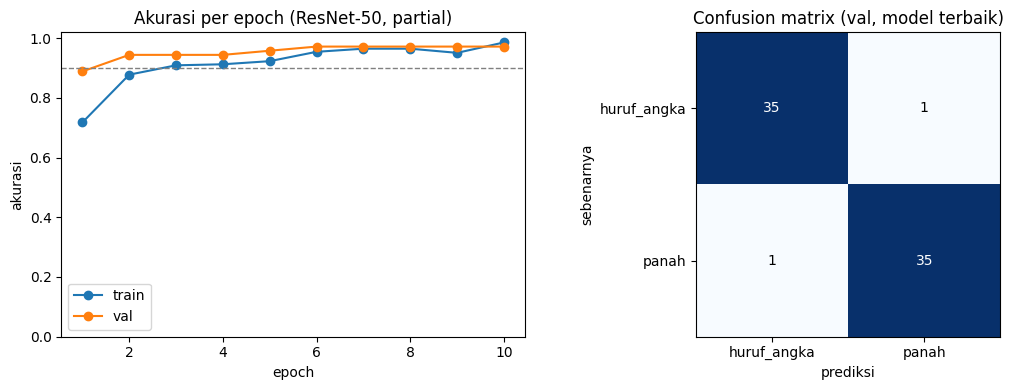


--- HASIL LATENSI ---
ResNet-50 CPU: 129.3 ms/gambar (~7.7 FPS) | jatah 35 ms: TIDAK muat
ResNet-50 GPU: 6.6 ms/gambar (~152.1 FPS) | jatah 35 ms: MUAT


In [ ]:
# Load bobot terbaik
model.load_state_dict(torch.load(f"best_{MODE}.pt", map_location=device))
_, final_acc, preds, labels = evaluate(model, val_dl)

# 1. Plot Confusion Matrix dan Tren Akurasi
K = len(classes)
cm = np.zeros((K, K), dtype=int)
for t, p in zip(labels, preds): cm[t, p] += 1

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ep_list = [h["epoch"] for h in history]
ax[0].plot(ep_list, [h["train_acc"] for h in history], marker="o", label="train")
ax[0].plot(ep_list, [h["val_acc"] for h in history], marker="o", label="val")
ax[0].axhline(0.9, ls="--", c="gray", lw=1)
ax[0].set(title=f"Akurasi per epoch (ResNet-50, {MODE})", xlabel="epoch", ylabel="akurasi", ylim=(0, 1.02))
ax[0].legend()
ax[1].imshow(cm, cmap="Blues")
ax[1].set(title="Confusion matrix (val, model terbaik)", xticks=range(K), yticks=range(K),
          xticklabels=classes, yticklabels=classes, xlabel="prediksi", ylabel="sebenarnya")
for i in range(K):
    for j in range(K):
        ax[1].text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.savefig(f"hasil_{MODE}.png", dpi=150); plt.show()

# 2. Ukur Latensi Inferensi
lat = {"cpu_ms": measure(model, "cpu")}
if torch.cuda.is_available():
    lat["gpu_ms"] = measure(model, "cuda")

print("\n--- HASIL LATENSI ---")
for k, v in lat.items():
    print(f"ResNet-50 {k[:3].upper()}: {v:.1f} ms/gambar (~{1000/v:.1f} FPS) | jatah 35 ms: {'MUAT' if v <= 35 else 'TIDAK muat'}")

# Simpan metadata hasil ke JSON & CSV
with open(f"history_{MODE}.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(history[0].keys())); w.writeheader(); w.writerows(history)

results = {"model": "resnet50", "mode": MODE, "best_val_acc": best_acc, "best_epoch": best_epoch,
           "epoch_first_val_acc_ge_90": epoch_ge_90, "train_time_sec": round(train_time, 1),
           "epochs": EPOCHS, "batch_size": BATCH_SIZE, "n_train": len(train_ds_new), "n_val": len(val_ds_new),
           "classes": classes, "device": device,
           "gpu": torch.cuda.get_device_name(0) if device == "cuda" else None,
           "latency": lat}
json.dump(results, open(f"hasil_{MODE}.json", "w"), indent=2)

## Langkah 7: Simpan & Unduh Hasil Baru

In [ ]:
import shutil
os.makedirs("hasil_baru", exist_ok=True)
for f in [f"hasil_{MODE}.png", f"hasil_{MODE}.json", f"history_{MODE}.csv"]:
    shutil.copy(f, "hasil_baru")
shutil.make_archive(f"hasil_resnet50_{MODE}_kustom", "zip", ".", "hasil_baru")
print("Arsip baru berhasil dibuat:", f"hasil_resnet50_{MODE}_kustom.zip")

try:
    from google.colab import files
    files.download(f"hasil_resnet50_{MODE}_kustom.zip")
except Exception as e:
    print("Gagal mendownload otomatis secara programatik:", e)

Arsip baru berhasil dibuat: hasil_resnet50_partial_kustom.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Latensi inferensi
Anggaran slide 16: 15 FPS = 67 ms per frame, jatah inferensi model sekitar 35 ms.

In [ ]:
def measure(m, dev, n_warm=10, n_run=100):
    m = m.to(dev).eval()
    x = torch.randn(1, 3, 224, 224, device=dev)
    with torch.no_grad():
        for _ in range(n_warm): m(x)
        if dev == "cuda": torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(n_run): m(x)
        if dev == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t) / n_run * 1000

lat = {"cpu_ms": measure(model, "cpu")}
if torch.cuda.is_available():
    lat["gpu_ms"] = measure(model, "cuda")
for k, v in lat.items():
    print(f"ResNet-50 {k[:3].upper()}: {v:.1f} ms/gambar (~{1000/v:.1f} FPS) | jatah 35 ms: {'MUAT' if v <= 35 else 'TIDAK muat'}")
results["latency"] = lat
json.dump(results, open(f"hasil_{MODE}.json", "w"), indent=2)
model.to(device)

ResNet-50 CPU: 125.6 ms/gambar (~8.0 FPS) | jatah 35 ms: TIDAK muat
ResNet-50 GPU: 7.3 ms/gambar (~137.9 FPS) | jatah 35 ms: MUAT


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 